# CLIP + Flan-T5 Model on PathVQA

This notebook trains a CLIP-based Med-VQA model on the **preprocessed PathVQA** dataset using a CLIP visual encoder and a Flan-T5 text encoder.

The goal is to compare this CLIP-based model against the MMQ baseline in `base-mmq-2.ipynb` using the same preprocessed data, batch size, and similar training setup (early stopping, LR scheduling, and detailed metrics for closed/open-ended questions).


In [1]:
# Install required packages
%pip install -q datasets transformers torch torchvision torchmetrics nltk evaluate

import nltk
nltk.download('punkt', quiet=True)

Note: you may need to restart the kernel to use updated packages.


True

In [2]:
# Imports
import os
import math
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from datasets import load_from_disk
from transformers import CLIPVisionModel, T5EncoderModel

import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
)

from nltk.translate.bleu_score import SmoothingFunction, sentence_bleu

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Enable cuDNN optimizations
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False  # Faster, but slight non-determinism

Using device: cuda


In [3]:
# Configuration
DATASET_DIR = "preprocessed_path_vqa"  # output from data-preprocessing.ipynb

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
FLAN_MODEL_NAME = "google/flan-t5-base"
BATCH_SIZE = 64  # A6000 optimized
EPOCHS = 30
LEARNING_RATE = 1e-4  # Reduced LR to prevent overfitting
WEIGHT_DECAY = 0.01  # Increased weight decay for stronger regularization
PATIENCE = 3  # Early stopping patience
LR_PATIENCE = 2  # ReduceLROnPlateau patience
LR_FACTOR = 0.5
MAX_GRAD_NORM = 1.0
LABEL_SMOOTHING = 0.1  # Label smoothing for better generalization
DROPOUT_RATE = 0.3  # Dropout for regularization (reduced to prevent underfitting)
FREEZE_ENCODERS = True  # Freeze pretrained encoders to prevent overfitting
TEMPERATURE = 1.0  # Temperature scaling for logits (can help with training stability)

# Performance optimizations (A6000 optimized)
NUM_WORKERS = 4  # Multi-process data loading
PIN_MEMORY = True  # Faster GPU transfer
PREFETCH_FACTOR = 2  # Prefetch batches

print("Config:")
print(f"  Dataset dir: {DATASET_DIR}")
print(f"  CLIP model: {CLIP_MODEL_NAME}")
print(f"  Flan model: {FLAN_MODEL_NAME}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  LR: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Label smoothing: {LABEL_SMOOTHING}")
print(f"  Dropout rate: {DROPOUT_RATE}")
print(f"  Freeze encoders: {FREEZE_ENCODERS}")
print(f"  Temperature: {TEMPERATURE}")
print(f"  Num workers: {NUM_WORKERS}")

Config:
  Dataset dir: preprocessed_path_vqa
  CLIP model: openai/clip-vit-base-patch32
  Flan model: google/flan-t5-base
  Batch size: 64
  Epochs: 30
  LR: 0.0001
  Weight decay: 0.01
  Label smoothing: 0.1
  Dropout rate: 0.3
  Freeze encoders: True
  Temperature: 1.0
  Num workers: 4


In [4]:
# Load preprocessed dataset
print("Loading preprocessed dataset from disk...")
dataset = load_from_disk(DATASET_DIR)
print(dataset)
print(f"Splits: {list(dataset.keys())}")

# Inspect one example for debug
sample = dataset["train"][0]
print("\nSample keys:", sample.keys())
print("Question:", sample["question"])
print("Answer:", sample["answer"])
print("Type:", sample["question_type"])
print("pixel_values shape: [C, H, W] =", len(sample["pixel_values"]), "x", len(sample["pixel_values"][0]), "x", len(sample["pixel_values"][0][0]))

Loading preprocessed dataset from disk...


/usr/local/lib/python3.11/dist-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer', 'question_type', 'input_ids', 'attention_mask', 'answer_input_ids', 'answer_attention_mask', 'pixel_values', 'image_size'],
        num_rows: 19654
    })
    validation: Dataset({
        features: ['image', 'question', 'answer', 'question_type', 'input_ids', 'attention_mask', 'answer_input_ids', 'answer_attention_mask', 'pixel_values', 'image_size'],
        num_rows: 6259
    })
    test: Dataset({
        features: ['image', 'question', 'answer', 'question_type', 'input_ids', 'attention_mask', 'answer_input_ids', 'answer_attention_mask', 'pixel_values', 'image_size'],
        num_rows: 6719
    })
})
Splits: ['train', 'validation', 'test']

Sample keys: dict_keys(['image', 'question', 'answer', 'question_type', 'input_ids', 'attention_mask', 'answer_input_ids', 'answer_attention_mask', 'pixel_values', 'image_size'])
Question: where are liver stem cells (oval cells) located?
Answer: in the canals of

In [5]:
# Build answer vocabulary from training split (same as MMQ baseline)
train_answers = dataset["train"]["answer"]

answer_counter = {}
for ans in train_answers:
    answer_counter[ans] = answer_counter.get(ans, 0) + 1

# Sort answers by frequency (descending) then alphabetically
sorted_answers = sorted(answer_counter.items(), key=lambda x: (-x[1], x[0]))

idx2ans = [ans for ans, _ in sorted_answers]
ans2idx = {ans: i for i, ans in enumerate(idx2ans)}
num_classes = len(idx2ans)

print(f"Number of unique answers (num_classes): {num_classes}")
print("Top 10 answers:")
for i, (ans, cnt) in enumerate(sorted_answers[:10]):
    print(f"  {i:2d}: '{ans}' (count={cnt})")

Number of unique answers (num_classes): 3225
Top 10 answers:
   0: 'yes' (count=5378)
   1: 'no' (count=4373)
   2: 'oral' (count=370)
   3: 'cardiovascular' (count=308)
   4: 'hematologic' (count=266)
   5: 'gastrointestinal' (count=264)
   6: 'endocrine' (count=250)
   7: 'lung' (count=208)
   8: 'hepatobiliary' (count=193)
   9: 'nervous' (count=178)


In [6]:
# Torch Dataset wrapper
class PathVQAClipDataset(Dataset):
    def __init__(self, hf_split):
        self.ds = hf_split

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]

        # Image tensor: [C, H, W]
        image = torch.tensor(item["pixel_values"], dtype=torch.float32)

        # Question tokens (from preprocessing)
        input_ids = torch.tensor(item["input_ids"], dtype=torch.long)
        attention_mask = torch.tensor(item["attention_mask"], dtype=torch.long)

        # Label index
        ans_text = item["answer"]
        label = ans2idx.get(ans_text, 0)
        label = torch.tensor(label, dtype=torch.long)

        q_type = item["question_type"]

        return {
            "image": image,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label,
            "question_type": q_type,
        }


train_dataset = PathVQAClipDataset(dataset["train"])
val_dataset = PathVQAClipDataset(dataset["validation"])
test_dataset = PathVQAClipDataset(dataset["test"])

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    prefetch_factor=PREFETCH_FACTOR if NUM_WORKERS > 0 else None
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    prefetch_factor=PREFETCH_FACTOR if NUM_WORKERS > 0 else None
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    prefetch_factor=PREFETCH_FACTOR if NUM_WORKERS > 0 else None
)

# Debug one batch
batch = next(iter(train_loader))
print("Batch debug:")
print("  image:", batch["image"].shape, batch["image"].dtype)
print("  input_ids:", batch["input_ids"].shape)
print("  attention_mask:", batch["attention_mask"].shape)
print("  label:", batch["label"].shape, batch["label"].dtype)
print("  question_type sample:", batch["question_type"][0])

Batch debug:
  image: torch.Size([64, 3, 224, 224]) torch.float32
  input_ids: torch.Size([64, 128])
  attention_mask: torch.Size([64, 128])
  label: torch.Size([64]) torch.int64
  question_type sample: closed-ended


In [7]:
# CLIP + Flan-T5 fusion model

class ClipFlanModel(nn.Module):
    def __init__(self, num_classes, clip_model_name=CLIP_MODEL_NAME, flan_model_name=FLAN_MODEL_NAME, freeze_encoders=True):
        super().__init__()

        print(f"Loading CLIP vision encoder from {clip_model_name} ...")
        self.vision = CLIPVisionModel.from_pretrained(clip_model_name)
        v_dim = self.vision.config.hidden_size
        
        # Freeze CLIP encoder to prevent overfitting
        if freeze_encoders:
            for param in self.vision.parameters():
                param.requires_grad = False
            print("  CLIP encoder frozen (not trainable)")

        print(f"Loading Flan-T5 encoder from {flan_model_name} ...")
        self.text_encoder = T5EncoderModel.from_pretrained(flan_model_name)
        t_dim = self.text_encoder.config.d_model
        
        # Freeze Flan-T5 encoder to prevent overfitting
        if freeze_encoders:
            for param in self.text_encoder.parameters():
                param.requires_grad = False
            print("  Flan-T5 encoder frozen (not trainable)")

        hidden_dim = 768  # Increased from 512 for more capacity
        self.v_proj = nn.Sequential(
            nn.Linear(v_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT_RATE)
        )
        self.q_proj = nn.Sequential(
            nn.Linear(t_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT_RATE)
        )
        
        # Enhanced fusion: concatenate + element-wise product for richer interaction
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),  # concat + prod = 3x
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT_RATE)
        )
        
        self.classifier = nn.Linear(hidden_dim, num_classes)
        
        # Initialize projection layers with Xavier/Kaiming init
        for module in [self.v_proj, self.q_proj, self.fusion]:
            for layer in module:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)
        
        # Better initialization for classifier: smaller weights to prevent extreme logits
        # This helps with training stability and reduces initial loss
        nn.init.normal_(self.classifier.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, images, input_ids, attention_mask):
        # CLIP expects pixel values [B, C, H, W] float32
        vision_outputs = self.vision(pixel_values=images)
        # Use pooled embedding if available, else global average pool
        if hasattr(vision_outputs, "pooler_output") and vision_outputs.pooler_output is not None:
            v = vision_outputs.pooler_output  # [B, v_dim]
        else:
            v = vision_outputs.last_hidden_state.mean(dim=1)

        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        h = text_outputs.last_hidden_state  # [B, L, t_dim]
        # Use attention-weighted pooling: mask padding and normalize
        mask_expanded = attention_mask.unsqueeze(-1).float()  # [B, L, 1]
        # Compute attention weights based on token importance (using mean activation)
        token_importance = h.abs().mean(dim=-1, keepdim=True)  # [B, L, 1]
        attention_weights = torch.softmax(mask_expanded * token_importance, dim=1)  # [B, L, 1]
        q = (h * attention_weights).sum(dim=1)  # [B, t_dim]

        v_proj = self.v_proj(v)
        q_proj = self.q_proj(q)

        # Enhanced fusion: concatenate visual, question, and their element-wise product
        # This allows the model to learn both independent and interactive features
        element_wise_prod = v_proj * q_proj
        fused_features = torch.cat([v_proj, q_proj, element_wise_prod], dim=-1)  # [B, hidden_dim * 3]
        fused = self.fusion(fused_features)
        
        logits = self.classifier(fused)
        
        # Apply temperature scaling to logits for better training stability
        # This helps prevent extreme logit values that lead to high loss
        if TEMPERATURE != 1.0:
            logits = logits / TEMPERATURE
        
        return logits


model = ClipFlanModel(num_classes=num_classes, freeze_encoders=FREEZE_ENCODERS).to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via DataParallel")
    model = nn.DataParallel(model)

# Label smoothing loss for better generalization
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999))
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE, verbose=True, min_lr=1e-6)

# Metrics for closed-ended (multi-class)
acc_metric = MulticlassAccuracy(num_classes=num_classes, average="micro").to(device)
prec_metric = MulticlassPrecision(num_classes=num_classes, average="weighted").to(device)
recall_metric = MulticlassRecall(num_classes=num_classes, average="weighted").to(device)
f1_metric = MulticlassF1Score(num_classes=num_classes, average="weighted").to(device)

print("Model initialized.")

Loading CLIP vision encoder from openai/clip-vit-base-patch32 ...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

  CLIP encoder frozen (not trainable)
Loading Flan-T5 encoder from google/flan-t5-base ...
  Flan-T5 encoder frozen (not trainable)
Model initialized.


In [8]:
# Inspect model architecture
print("\n===== CLIP + Flan-T5 Model Architecture =====")
print(model)

# Parameter counts
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")


===== CLIP + Flan-T5 Model Architecture =====
ClipFlanModel(
  (vision): CLIPVisionModel(
    (vision_model): CLIPVisionTransformer(
      (embeddings): CLIPVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
        (position_embedding): Embedding(50, 768)
      )
      (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activatio

In [9]:
# Helper: compute open-ended metrics from predicted/true answers

def compute_open_ended_metrics(pred_texts, true_texts):
    assert len(pred_texts) == len(true_texts)

    exact_matches = 0
    word_overlaps = []
    bleu_scores = []

    smooth = SmoothingFunction().method1

    for pred, gold in zip(pred_texts, true_texts):
        p = pred.lower().strip()
        g = gold.lower().strip()

        # Exact match
        if p == g:
            exact_matches += 1

        # Word overlap
        g_words = set(g.split())
        if len(g_words) > 0:
            p_words = set(p.split())
            overlap = len(p_words & g_words) / len(g_words)
            word_overlaps.append(overlap)

        # BLEU-1
        ref = [g.split()]
        hyp = p.split()
        bleu1 = sentence_bleu(ref, hyp, weights=(1, 0, 0, 0), smoothing_function=smooth)
        bleu_scores.append(bleu1)

    n = len(pred_texts)
    exact_match = exact_matches / n if n > 0 else 0.0
    avg_word_overlap = float(np.mean(word_overlaps)) if word_overlaps else 0.0
    avg_bleu1 = float(np.mean(bleu_scores)) if bleu_scores else 0.0

    return {
        "exact_match": exact_match,
        "word_overlap": avg_word_overlap,
        "bleu1": avg_bleu1,
    }

In [10]:
# Memory monitoring helper function
def print_gpu_memory(stage=""):
    """Print detailed GPU memory usage information"""
    if not torch.cuda.is_available():
        print(f"{stage}: CUDA not available")
        return
    
    allocated = torch.cuda.memory_allocated(0) / 1024**3  # GB
    reserved = torch.cuda.memory_reserved(0) / 1024**3  # GB
    max_allocated = torch.cuda.max_memory_allocated(0) / 1024**3  # GB
    max_reserved = torch.cuda.max_memory_reserved(0) / 1024**3  # GB
    
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3  # GB
    free_memory = total_memory - reserved
    
    print(f"\n{'='*60}")
    print(f"GPU Memory Status: {stage}")
    print(f"{'='*60}")
    print(f"  Total GPU Memory    : {total_memory:.2f} GB")
    print(f"  Allocated           : {allocated:.2f} GB ({allocated/total_memory*100:.1f}%)")
    print(f"  Reserved            : {reserved:.2f} GB ({reserved/total_memory*100:.1f}%)")
    print(f"  Free                : {free_memory:.2f} GB ({free_memory/total_memory*100:.1f}%)")
    print(f"  Peak Allocated      : {max_allocated:.2f} GB")
    print(f"  Peak Reserved       : {max_reserved:.2f} GB")
    print(f"{'='*60}\n")

# Check memory after model initialization
print_gpu_memory("After Model Initialization")


GPU Memory Status: After Model Initialization
  Total GPU Memory    : 47.53 GB
  Allocated           : 0.76 GB (1.6%)
  Reserved            : 0.84 GB (1.8%)
  Free                : 46.69 GB (98.2%)
  Peak Allocated      : 0.76 GB
  Peak Reserved       : 0.84 GB



In [11]:
# Training and evaluation loops with detailed metrics


def run_epoch(loader, model, optimizer=None, epoch_idx=0, train=True):
    if train:
        model.train()
    else:
        model.eval()

    # Reset metrics each epoch to avoid state leakage
    acc_metric.reset()
    prec_metric.reset()
    recall_metric.reset()
    f1_metric.reset()

    total_loss = 0.0
    n_batches = 0

    # Accumulate for closed-ended metrics
    all_labels = []
    all_preds = []

    # For open-ended metrics
    open_pred_texts = []
    open_true_texts = []

    for batch_idx, batch in enumerate(tqdm(loader, desc="Train" if train else "Eval")):
        # Use non_blocking for faster transfer when using pin_memory
        images = batch["image"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)
        q_types = batch["question_type"]

        if train:
            optimizer.zero_grad()

        logits = model(images, input_ids, attention_mask)
        loss = criterion(logits, labels)
        
        # Check for NaN/Inf
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"[WARNING] NaN/Inf loss detected at batch {batch_idx}, skipping...")
            continue

        if train:
            loss.backward()
            # Check for NaN gradients
            has_nan_grad = False
            for param in model.parameters():
                if param.grad is not None and torch.isnan(param.grad).any():
                    has_nan_grad = True
                    break
            
            if has_nan_grad:
                print(f"[WARNING] NaN gradient detected at batch {batch_idx}, skipping...")
                optimizer.zero_grad()
                continue
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            
            # Clear cache periodically to avoid memory fragmentation
            if batch_idx % 50 == 0:
                torch.cuda.empty_cache()

        total_loss += loss.item()
        n_batches += 1

        preds = torch.argmax(logits, dim=1)
        preds_cpu = preds.detach().cpu()
        labels_cpu = labels.detach().cpu()
        all_labels.append(labels_cpu)
        all_preds.append(preds_cpu)

        # Collect open-ended metrics (based on question_type)
        for i in range(len(labels)):
            ans_pred = idx2ans[preds[i].item()]
            ans_true = idx2ans[labels[i].item()]
            if q_types[i] == "open-ended":
                open_pred_texts.append(ans_pred)
                open_true_texts.append(ans_true)

        # Debug: print first batch shapes and sample predictions
        if batch_idx == 0:
            print(f"[DEBUG] epoch {epoch_idx} | train={train} | logits shape={logits.shape}")
            print("[DEBUG] sample pred ids:", preds[:5].tolist())
            print("[DEBUG] sample true ids:", labels[:5].tolist())
        
        # Delete large tensors to free memory
        del logits, preds
        if train:
            del loss

    avg_loss = total_loss / max(1, n_batches)

    all_labels_tensor = torch.cat(all_labels)
    all_preds_tensor = torch.cat(all_preds)

    # Closed-ended metrics over all questions
    acc = acc_metric(all_preds_tensor.to(device), all_labels_tensor.to(device)).item()
    prec = prec_metric(all_preds_tensor.to(device), all_labels_tensor.to(device)).item()
    rec = recall_metric(all_preds_tensor.to(device), all_labels_tensor.to(device)).item()
    f1 = f1_metric(all_preds_tensor.to(device), all_labels_tensor.to(device)).item()

    # Open-ended metrics
    open_metrics = compute_open_ended_metrics(open_pred_texts, open_true_texts)

    metrics = {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "open_bleu1": open_metrics["bleu1"],
        "open_exact": open_metrics["exact_match"],
        "open_word_overlap": open_metrics["word_overlap"],
    }

    return metrics


def print_metrics(prefix, metrics):
    print(f"{prefix} | "
          f"loss={metrics['loss']:.4f} "
          f"acc={metrics['accuracy']:.4f} "
          f"prec={metrics['precision']:.4f} "
          f"rec={metrics['recall']:.4f} "
          f"f1={metrics['f1']:.4f} | "
          f"open_bleu1={metrics['open_bleu1']:.4f} "
          f"open_exact={metrics['open_exact']:.4f} "
          f"open_overlap={metrics['open_word_overlap']:.4f}")

In [12]:
# Training loop with early stopping and ReduceLROnPlateau

best_val_loss = float("inf")
best_val_f1 = 0.0
best_val_bleu1 = 0.0
best_combined_score = 0.0
best_state = None
no_improve_epochs = 0

# Initialize fit tracking variables to avoid scope issues
is_overfitting = False
is_underfitting = False

# Track consecutive epochs of overfitting/underfitting for LR reduction
consecutive_overfitting_epochs = 0
consecutive_underfitting_epochs = 0
history = []

# Helper function to get model state_dict (handles DataParallel)
def get_model_state_dict(model):
    """Get state dict, handling DataParallel wrapper"""
    if isinstance(model, nn.DataParallel):
        return model.module.state_dict()
    return model.state_dict()

# Helper function to load model state_dict (handles DataParallel)
def load_model_state_dict(model, state_dict):
    """Load state dict, handling DataParallel wrapper"""
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(state_dict)
    else:
        model.load_state_dict(state_dict)

# Clear GPU cache before training - IMPORTANT if restarting training
torch.cuda.empty_cache()

# Reset peak memory stats for training
torch.cuda.reset_peak_memory_stats(0)

print_gpu_memory("After Warm-up Forward+Backward Pass (Realistic Training Memory)")

# Clear cache and reset for actual training
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(0)

# Loss explanation for many classes
print(f"\n[INFO] Training with {num_classes} classes.")
print(f"[INFO] Expected loss range:")
print(f"  - Random classifier: ~{np.log(num_classes):.2f}")
print(f"  - Perfect classifier (with label_smoothing={LABEL_SMOOTHING}): ~{-np.log(1 - LABEL_SMOOTHING):.3f}")
print(f"  - Typical good model: 2.0-4.0 (depends on class distribution)")
print(f"[INFO] Loss of 3.3-3.4 is reasonable for {num_classes} classes.\n")

for epoch in range(1, EPOCHS + 1):
    print("\n" + "=" * 80)
    print(f"Epoch {epoch}/{EPOCHS}")
    print("=" * 80)
    
    # Clear cache at start of each epoch
    if epoch > 1:
        torch.cuda.empty_cache()

    train_metrics = run_epoch(train_loader, model, optimizer=optimizer, epoch_idx=epoch, train=True)
    torch.cuda.empty_cache()  # Clear cache between train and val
    
    with torch.no_grad():
        val_metrics = run_epoch(val_loader, model, optimizer=None, epoch_idx=epoch, train=False)

    # Step LR scheduler on validation loss
    scheduler.step(val_metrics["loss"])

    # Check for overfitting/underfitting EVERY epoch (not just when improved)
    train_loss = train_metrics["loss"]
    val_loss = val_metrics["loss"]
    train_acc = train_metrics["accuracy"]
    val_acc = val_metrics["accuracy"]
    train_f1 = train_metrics["f1"]
    val_f1 = val_metrics["f1"]
    
    # Calculate gaps
    loss_gap = train_loss - val_loss
    acc_gap = train_acc - val_acc
    f1_gap = train_f1 - val_f1
    
    # Overfitting detection
    is_overfitting_epoch = False
    if loss_gap < -0.1 or acc_gap > 0.15 or f1_gap > 0.15:
        is_overfitting_epoch = True
    
    # Underfitting detection
    is_underfitting_epoch = False
    if (train_acc < 0.3 and val_acc < 0.3) or (train_f1 < 0.3 and val_f1 < 0.3) or (val_loss > np.log(num_classes) * 0.8):
        is_underfitting_epoch = True
    
    # Track consecutive epochs and reduce LR if needed
    if is_overfitting_epoch:
        consecutive_overfitting_epochs += 1
        consecutive_underfitting_epochs = 0  # Reset opposite counter
        if consecutive_overfitting_epochs >= 2:
            old_lr = optimizer.param_groups[0]["lr"]
            new_lr = old_lr * LR_FACTOR
            for param_group in optimizer.param_groups:
                param_group["lr"] = max(new_lr, 1e-6)
            print(f"[LR REDUCTION] Overfitting for {consecutive_overfitting_epochs} epochs. LR: {old_lr:.6f} -> {optimizer.param_groups[0]['lr']:.6f}")
            consecutive_overfitting_epochs = 0
    elif is_underfitting_epoch:
        consecutive_underfitting_epochs += 1
        consecutive_overfitting_epochs = 0  # Reset opposite counter
        if consecutive_underfitting_epochs >= 2:
            old_lr = optimizer.param_groups[0]["lr"]
            new_lr = old_lr * LR_FACTOR
            for param_group in optimizer.param_groups:
                param_group["lr"] = max(new_lr, 1e-6)
            print(f"[LR REDUCTION] Underfitting for {consecutive_underfitting_epochs} epochs. LR: {old_lr:.6f} -> {optimizer.param_groups[0]['lr']:.6f}")
            consecutive_underfitting_epochs = 0
    else:
        # Fit is healthy - reset both counters
        consecutive_overfitting_epochs = 0
        consecutive_underfitting_epochs = 0
    
    print_metrics("Train", train_metrics)
    print_metrics("Val  ", val_metrics)
    
    # Print peak memory usage after first epoch to show actual training memory
    if epoch == 1:
        print("\n[INFO] Peak memory usage after first epoch:")
        peak_allocated = torch.cuda.max_memory_allocated(0) / 1024**3
        peak_reserved = torch.cuda.max_memory_reserved(0) / 1024**3
        print(f"  Peak Allocated: {peak_allocated:.2f} GB")
        print(f"  Peak Reserved: {peak_reserved:.2f} GB")
        print(f"  Current Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

    history.append({
        "epoch": epoch,
        "train": train_metrics,
        "val": val_metrics,
        "lr": optimizer.param_groups[0]["lr"],
    })
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping: use combined F1 and BLEU-1 score for model selection
    # This considers both closed-ended (F1) and open-ended (BLEU-1) performance
    current_f1 = val_metrics["f1"]
    current_bleu1 = val_metrics["open_bleu1"]
    
    # Combined score: weighted average of F1 and BLEU-1 (favor F1 slightly for balanced performance)
    # Scale BLEU-1 to similar range as F1 (BLEU is typically 0-1, F1 is also 0-1)
    combined_score = 0.7 * current_f1 + 0.3 * current_bleu1
    
    improved = False
    
    # Check if either F1 or BLEU-1 improved, or if combined score improved
    if current_f1 > best_val_f1 + 1e-4:  # F1 improved
        best_val_f1 = current_f1
        improved = True
    
    if current_bleu1 > best_val_bleu1 + 1e-4:  # BLEU-1 improved
        best_val_bleu1 = current_bleu1
        improved = True
    
    # Also consider combined score improvement (recalculate after updating best values)
    current_best_combined_score = 0.7 * best_val_f1 + 0.3 * best_val_bleu1
    if combined_score > current_best_combined_score + 1e-4:
        improved = True
        best_combined_score = combined_score
    else:
        # Update best_combined_score based on updated best values
        best_combined_score = current_best_combined_score
    
    if val_metrics["loss"] < best_val_loss - 1e-4:  # Loss improved
        best_val_loss = val_metrics["loss"]
    
    if improved:
        # Use already-calculated values from earlier (train_loss, val_loss, etc. are already set)
        # Overfitting detection (detailed with signs for logging)
        is_overfitting = False
        overfitting_signs = []
        if loss_gap < -0.1:
            is_overfitting = True
            overfitting_signs.append(
                f"Loss gap: {loss_gap:.4f} (val_loss much higher than train_loss)"
            )
        if acc_gap > 0.15:
            is_overfitting = True
            overfitting_signs.append(
                f"Acc gap: {acc_gap:.4f} (train_acc much higher than val_acc)"
            )
        if f1_gap > 0.15:
            is_overfitting = True
            overfitting_signs.append(
                f"F1 gap: {f1_gap:.4f} (train_f1 much higher than val_f1)"
            )

        # Underfitting detection
        is_underfitting = False
        underfitting_signs = []
        if train_acc < 0.3 and val_acc < 0.3:
            is_underfitting = True
            underfitting_signs.append(
                f"Both train_acc ({train_acc:.4f}) and val_acc ({val_acc:.4f}) are low (< 0.3)"
            )
        if train_f1 < 0.3 and val_f1 < 0.3:
            is_underfitting = True
            underfitting_signs.append(
                f"Both train_f1 ({train_f1:.4f}) and val_f1 ({val_f1:.4f}) are low (< 0.3)"
            )
        if val_loss > np.log(num_classes) * 0.8:
            is_underfitting = True
            underfitting_signs.append(
                f"Val loss ({val_loss:.4f}) is close to random baseline (~{np.log(num_classes):.2f})"
            )

        print(
            f"[INFO] Validation improved - "
            f"F1: {current_f1:.4f}, BLEU-1: {current_bleu1:.4f}, "
            f"Combined: {combined_score:.4f}"
        )

        # ---- SAVE ONLY IF FIT IS HEALTHY ----
        if is_overfitting or is_underfitting:
            print("[INFO] Model improved but will NOT be saved due to fit issues.")
            print("[INFO] Treating as no usable improvement for patience tracking.")

            if is_overfitting:
                print("[WARNING] Overfitting detected!")
                for sign in overfitting_signs:
                    print(f"  - {sign}")
                print(
                    "  Recommendation: Increase regularization, freeze more layers, "
                    "or apply stronger data augmentation."
                )

            if is_underfitting:
                print("[WARNING] Underfitting detected!")
                for sign in underfitting_signs:
                    print(f"  - {sign}")
                print(
                    "  Recommendation: Increase model capacity, unfreeze encoders, "
                    "or train longer."
                )
            
            # Increment patience since this improvement is not usable
            no_improve_epochs += 1
            print(f"[INFO] No usable improvement for {no_improve_epochs} epoch(s) (counting unhealthy improvements)")
            if best_state is not None:
                print(f"       Best healthy F1: {best_state['val_f1']:.4f} (Epoch {best_state['epoch']})")
            else:
                print(f"       No healthy model saved yet")
            if no_improve_epochs >= PATIENCE:
                print("[EARLY STOPPING] Patience exceeded, stopping training.")
                break

        else:
            # Model is healthy - save it
            best_state = {
                "model": get_model_state_dict(model),  # Handle DataParallel properly
                "optimizer": optimizer.state_dict(),
                "epoch": epoch,
                "val_loss": val_loss,
                "val_f1": current_f1,
                "val_acc": val_acc,
                "train_loss": train_loss,
                "train_f1": train_f1,
                "train_acc": train_acc,
                "val_bleu1": current_bleu1,
                "combined_score": combined_score,
                "is_overfitting": False,
                "is_underfitting": False,
                "loss_gap": loss_gap,
                "acc_gap": acc_gap,
                "f1_gap": f1_gap,
            }
            no_improve_epochs = 0
            print("[INFO] Fit is healthy. Best model state saved.")

    else:
        # No improvement at all
        no_improve_epochs += 1
        print(f"[INFO] No improvement for {no_improve_epochs} epoch(s)")
        print(
            f"       Best F1: {best_val_f1:.4f}, "
            f"Best BLEU-1: {best_val_bleu1:.4f}, "
            f"Best Combined: {best_combined_score:.4f}"
        )
        if no_improve_epochs >= PATIENCE:
            print("[EARLY STOPPING] Patience exceeded, stopping training.")
            break

# Load best model state for evaluation
if best_state is not None:
    print(f"\n{'='*80}")
    print(f"BEST MODEL ANALYSIS (Epoch {best_state['epoch']})")
    print(f"{'='*80}")
    print(f"  Val loss: {best_state['val_loss']:.4f}")
    print(f"  Val F1: {best_state.get('val_f1', 'N/A'):.4f}")
    print(f"  Val Acc: {best_state.get('val_acc', 'N/A'):.4f}")
    print(f"  Val BLEU-1: {best_state.get('val_bleu1', 'N/A'):.4f}")
    print(f"  Combined Score: {best_state.get('combined_score', 'N/A'):.4f}")
    print(f"\n  Train loss: {best_state.get('train_loss', 'N/A'):.4f}")
    print(f"  Train F1: {best_state.get('train_f1', 'N/A'):.4f}")
    print(f"  Train Acc: {best_state.get('train_acc', 'N/A'):.4f}")
    
    # Fit analysis (best_state only contains healthy models)
    print(f"\n  Fit Analysis:")
    print(f"    Loss gap (train - val): {best_state.get('loss_gap', 'N/A'):.4f}")
    print(f"    Acc gap (train - val): {best_state.get('acc_gap', 'N/A'):.4f}")
    print(f"    F1 gap (train - val): {best_state.get('f1_gap', 'N/A'):.4f}")
    print(f"    Status: [OK] Model fit is healthy (only healthy models are saved)")
    
    # Load best model state (handles DataParallel properly)
    load_model_state_dict(model, best_state["model"])

		# Save best model to disk
    model_save_path = "best_model_clip_flant5.pth"
    save_dict = {
        "model_state_dict": best_state["model"],
        "optimizer_state_dict": best_state["optimizer"],
        "epoch": best_state["epoch"],
        "val_loss": best_state["val_loss"],
        "val_f1": best_state.get("val_f1", 0.0),
        "val_acc": best_state.get("val_acc", 0.0),
        "val_bleu1": best_state.get("val_bleu1", 0.0),
        "train_loss": best_state.get("train_loss", 0.0),
        "train_f1": best_state.get("train_f1", 0.0),
        "train_acc": best_state.get("train_acc", 0.0),
        "combined_score": best_state.get("combined_score", 0.0),
        "is_overfitting": best_state.get("is_overfitting", False),  # Always False for saved healthy models
        "is_underfitting": best_state.get("is_underfitting", False),  # Always False for saved healthy models
        "loss_gap": best_state.get("loss_gap", 0.0),
        "acc_gap": best_state.get("acc_gap", 0.0),
        "f1_gap": best_state.get("f1_gap", 0.0),
        "num_classes": num_classes,
        "idx2ans": idx2ans,
        "ans2idx": ans2idx,
        "config": {
            "clip_model_name": CLIP_MODEL_NAME,
            "flan_model_name": FLAN_MODEL_NAME,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
        }
    }
    torch.save(save_dict, model_save_path)
    print(f"\n[INFO] Best healthy model saved to {model_save_path}")
else:
    print(f"\n{'='*80}")
    print("NO HEALTHY MODEL FOUND")
    print(f"{'='*80}")
    print("[WARNING] No healthy model was saved during training.")
    print("This means all improvements showed signs of overfitting or underfitting.")
    print("Consider adjusting hyperparameters or training longer.")


GPU Memory Status: After Warm-up Forward+Backward Pass (Realistic Training Memory)
  Total GPU Memory    : 47.53 GB
  Allocated           : 0.76 GB (1.6%)
  Reserved            : 0.84 GB (1.8%)
  Free                : 46.69 GB (98.2%)
  Peak Allocated      : 0.76 GB
  Peak Reserved       : 0.84 GB


[INFO] Training with 3225 classes.
[INFO] Expected loss range:
  - Random classifier: ~8.08
  - Perfect classifier (with label_smoothing=0.1): ~0.105
  - Typical good model: 2.0-4.0 (depends on class distribution)
[INFO] Loss of 3.3-3.4 is reasonable for 3225 classes.


Epoch 1/30


Train:   0%|          | 0/308 [00:02<?, ?it/s]

[DEBUG] epoch 1 | train=True | logits shape=torch.Size([64, 3225])
[DEBUG] sample pred ids: [2810, 801, 64, 332, 761]
[DEBUG] sample true ids: [19, 0, 17, 169, 0]


Eval:   0%|          | 0/98 [00:00<?, ?it/s]

[DEBUG] epoch 1 | train=False | logits shape=torch.Size([64, 3225])
[DEBUG] sample pred ids: [1, 0, 0, 1, 7]
[DEBUG] sample true ids: [2126, 2126, 0, 0, 0]
Train | loss=4.5259 acc=0.3455 prec=0.2481 rec=0.3455 f1=0.2813 | open_bleu1=0.0485 open_exact=0.0473 open_overlap=0.0489
Val   | loss=3.4422 acc=0.4668 prec=0.4748 rec=0.4668 f1=0.4561 | open_bleu1=0.1849 open_exact=0.1822 open_overlap=0.1853

[INFO] Peak memory usage after first epoch:
  Peak Allocated: 1.28 GB
  Peak Reserved: 1.70 GB
  Current Allocated: 0.84 GB
Current LR: 0.000100
[INFO] Validation improved - F1: 0.4561, BLEU-1: 0.1849, Combined: 0.3747
[INFO] Fit is healthy. Best model state saved.

Epoch 2/30


...

[DEBUG] epoch 8 | train=False | logits shape=torch.Size([64, 3225])
[DEBUG] sample pred ids: [118, 1, 0, 256, 55]
[DEBUG] sample true ids: [2126, 2126, 0, 0, 0]
[LR REDUCTION] Overfitting for 2 epochs. LR: 0.000100 -> 0.000050
Train | loss=2.9296 acc=0.5689 prec=0.5004 rec=0.5689 f1=0.5232 | open_bleu1=0.3367 open_exact=0.3306 open_overlap=0.3404
Val   | loss=3.1652 acc=0.5456 prec=0.6010 rec=0.5456 f1=0.5518 | open_bleu1=0.2877 open_exact=0.2843 open_overlap=0.2888
Current LR: 0.000050
[INFO] Validation improved - F1: 0.5518, BLEU-1: 0.2877, Combined: 0.4726
[INFO] Model improved but will NOT be saved due to fit issues.
[INFO] Treating as no usable improvement for patience tracking.
[WARNING] Overfitting detected!
  - Loss gap: -0.2356 (val_loss much higher than train_loss)
  Recommendation: Increase regularization, freeze more layers, or apply stronger data augmentation.
[INFO] No usable improvement for 2 epoch(s) (counting unhealthy improvements)
       Best healthy F1: 0.5394 (Epoc

Train:   0%|          | 0/308 [00:00<?, ?it/s]

[DEBUG] epoch 9 | train=True | logits shape=torch.Size([64, 3225])
[DEBUG] sample pred ids: [31, 3, 3, 1, 3]
[DEBUG] sample true ids: [83, 41, 3, 1, 3]


Eval:   0%|          | 0/98 [00:00<?, ?it/s]

[DEBUG] epoch 9 | train=False | logits shape=torch.Size([64, 3225])
[DEBUG] sample pred ids: [118, 1, 1, 256, 55]
[DEBUG] sample true ids: [2126, 2126, 0, 0, 0]
Train | loss=2.8128 acc=0.5826 prec=0.5145 rec=0.5826 f1=0.5362 | open_bleu1=0.3585 open_exact=0.3521 open_overlap=0.3625
Val   | loss=3.1815 acc=0.5506 prec=0.6160 rec=0.5506 f1=0.5577 | open_bleu1=0.2881 open_exact=0.2849 open_overlap=0.2892
Current LR: 0.000050
[INFO] Validation improved - F1: 0.5577, BLEU-1: 0.2881, Combined: 0.4768
[INFO] Model improved but will NOT be saved due to fit issues.
[INFO] Treating as no usable improvement for patience tracking.
[WARNING] Overfitting detected!
  - Loss gap: -0.3687 (val_loss much higher than train_loss)
  Recommendation: Increase regularization, freeze more layers, or apply stronger data augmentation.
[INFO] No usable improvement for 3 epoch(s) (counting unhealthy improvements)
       Best healthy F1: 0.5394 (Epoch 6)
[EARLY STOPPING] Patience exceeded, stopping training.

BEST 

In [13]:
# Final evaluation on test set
with torch.no_grad():
    test_metrics = run_epoch(test_loader, model, optimizer=None, epoch_idx=0, train=False)

print("\n" + "=" * 80)
print("FINAL TEST METRICS (CLIP + Flan-T5)")
print("=" * 80)
print_metrics("Test ", test_metrics)

Eval:   0%|          | 0/105 [00:00<?, ?it/s]

[DEBUG] epoch 0 | train=False | logits shape=torch.Size([64, 3225])
[DEBUG] sample pred ids: [55, 62, 118, 1, 55]
[DEBUG] sample true ids: [0, 0, 0, 0, 124]

FINAL TEST METRICS (CLIP + Flan-T5)
Test  | loss=3.1994 acc=0.5456 prec=0.6093 rec=0.5456 f1=0.5523 | open_bleu1=0.2855 open_exact=0.2790 open_overlap=0.2880



QUALITATIVE INFERENCES (TEST SET)


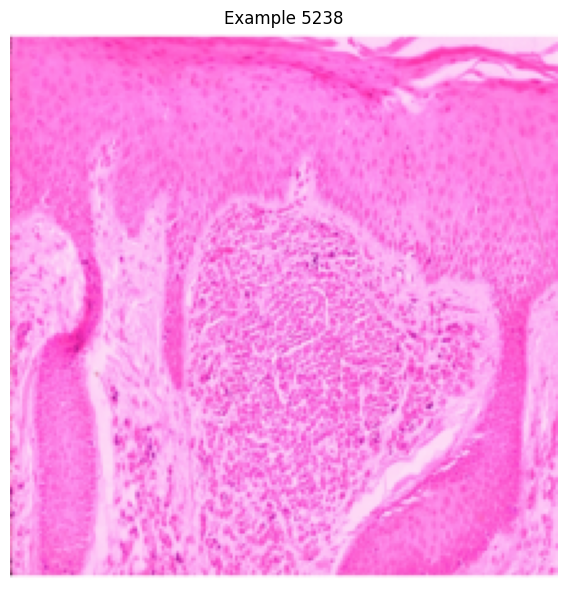

--------------------------------------------------------------------------------
Question type : open-ended
Question      : what does this image show?
GT answer     : yes
Predicted ans : mucocele



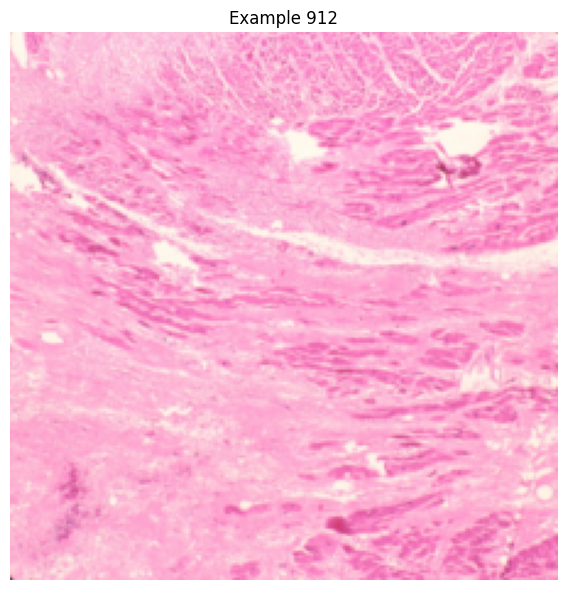

--------------------------------------------------------------------------------
Question type : open-ended
Question      : what is present?
GT answer     : cardiovascular
Predicted ans : cardiovascular



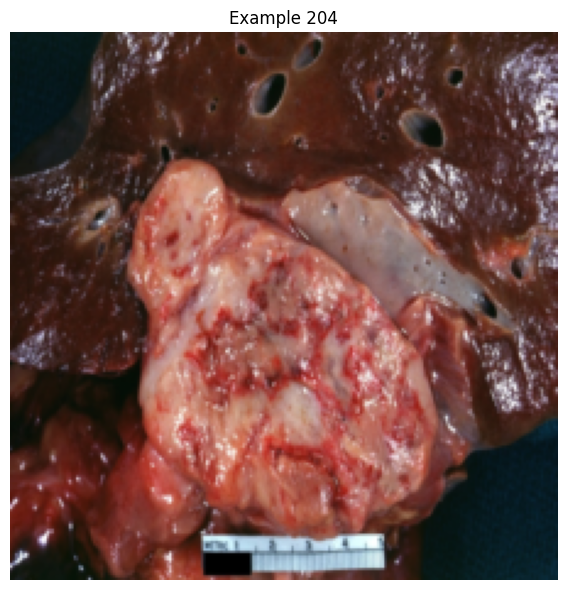

--------------------------------------------------------------------------------
Question type : open-ended
Question      : what is present?
GT answer     : yes
Predicted ans : hepatobiliary



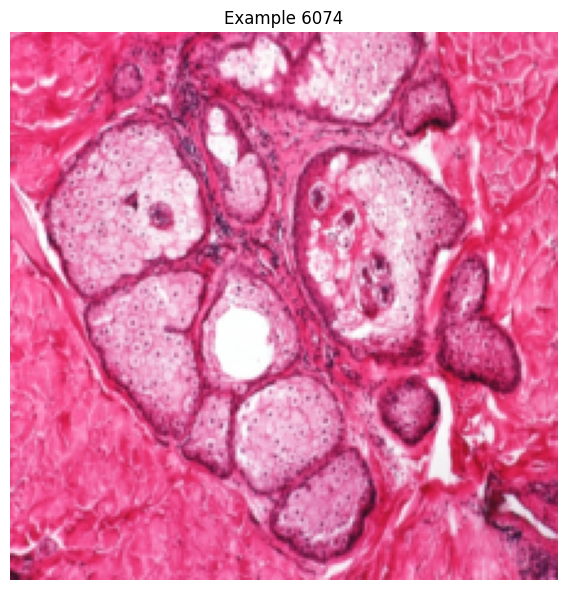

--------------------------------------------------------------------------------
Question type : open-ended
Question      : what is present?
GT answer     : yes
Predicted ans : hematologic



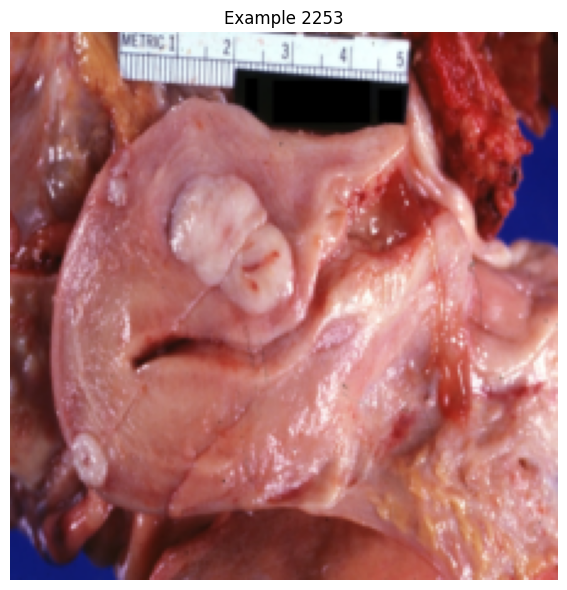

--------------------------------------------------------------------------------
Question type : closed-ended
Question      : is female reproductive present?
GT answer     : yes
Predicted ans : yes



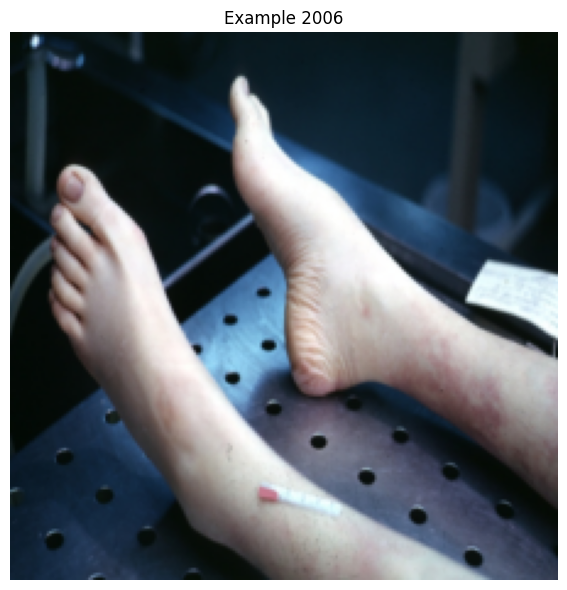

--------------------------------------------------------------------------------
Question type : open-ended
Question      : what are present?
GT answer     : extremities
Predicted ans : extremities



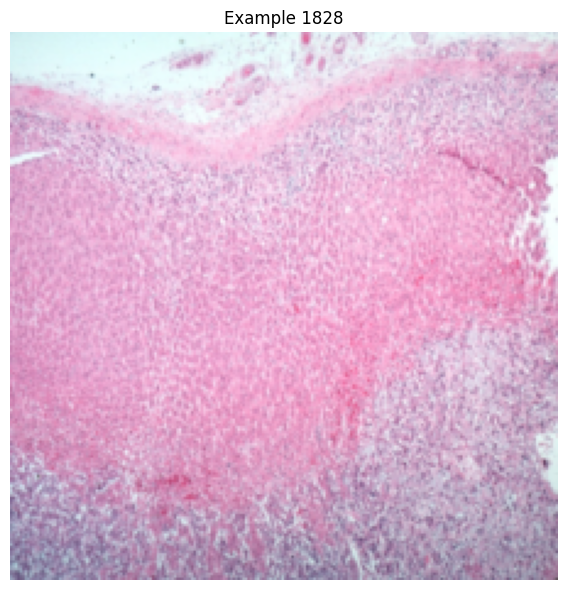

--------------------------------------------------------------------------------
Question type : open-ended
Question      : what does this image show?
GT answer     : primary in stomach
Predicted ans : pancreatic fat necrosis



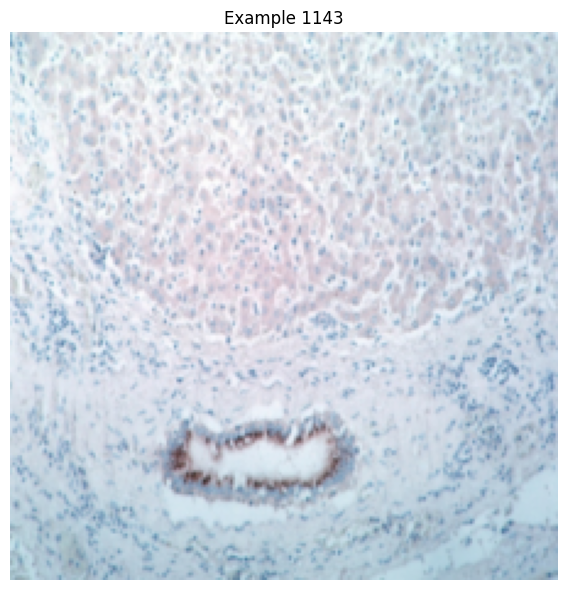

--------------------------------------------------------------------------------
Question type : open-ended
Question      : what is present?
GT answer     : cardiovascular
Predicted ans : cardiovascular



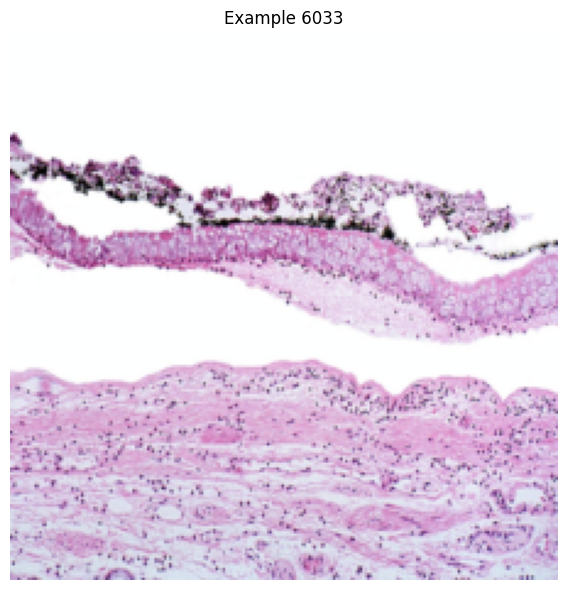

--------------------------------------------------------------------------------
Question type : open-ended
Question      : where is this?
GT answer     : skin
Predicted ans : skin



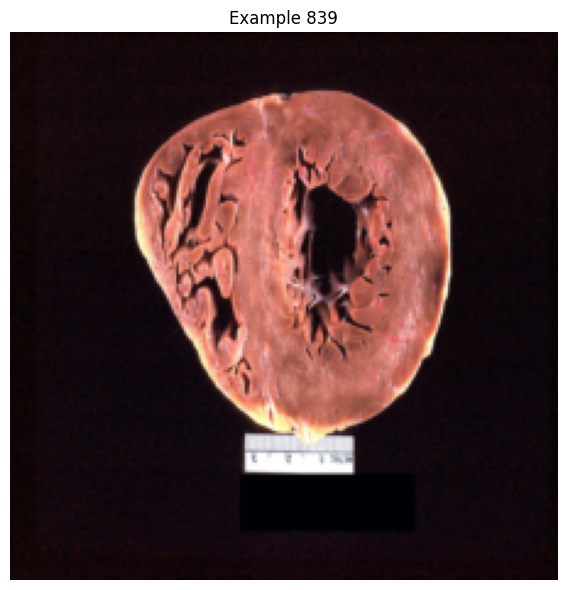

--------------------------------------------------------------------------------
Question type : closed-ended
Question      : is cardiovascular present?
GT answer     : yes
Predicted ans : yes



In [14]:
# Qualitative inferences on a few test examples
model.eval()

num_examples = 10
indices = random.sample(range(len(test_dataset)), num_examples)

print("\n" + "=" * 80)
print("QUALITATIVE INFERENCES (TEST SET)")
print("=" * 80)

for idx in indices:
    ex = test_dataset[idx]

    image = ex["image"].unsqueeze(0).to(device)
    input_ids = ex["input_ids"].unsqueeze(0).to(device)
    attention_mask = ex["attention_mask"].unsqueeze(0).to(device)
    label = ex["label"].item()
    q_type = ex["question_type"]

    with torch.no_grad():
        logits = model(image, input_ids, attention_mask)
        pred = torch.argmax(logits, dim=1).item()

    gt_text = idx2ans[label]
    pred_text = idx2ans[pred]

    # Display image - denormalize to show original colors
    img_tensor = ex["image"]  # [C, H, W], normalized with ImageNet stats
    
    # ImageNet normalization values (from preprocessing)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Denormalize: original = (normalized * std) + mean
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)  # Ensure values are in [0, 1] for display
    
    plt.figure(figsize=(8, 6))
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(f"Example {idx}", fontsize=12)
    plt.tight_layout()
    plt.show()

    print("-" * 80)
    print(f"Question type : {q_type}")
    print(f"Question      : {dataset['test'][idx]['question']}")
    print(f"GT answer     : {gt_text}")
    print(f"Predicted ans : {pred_text}")
    print()